## Infinite Bases

The idea of learning dictionary functions that we explore relies on deforming an original dictionary. Therefore, it is first natural to implement different initial bases to deform. In this notebook, we will cover multiple examples of basis functions on different domains $\Omega$.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Box Basis on a Square

Here we take $\Omega = [0,1]^d$ and use the standard for each grid node $x_i \in \Omega$, we define a continuous, piecewise-constant function $e_i$ that satisfies $e_i(x_i)=1$ when $x_i$ is within a certain box and zero otherwise.



Run the code below to visualize these basis functions on a coarse $3\times 3$ resolution on a 2D domain.

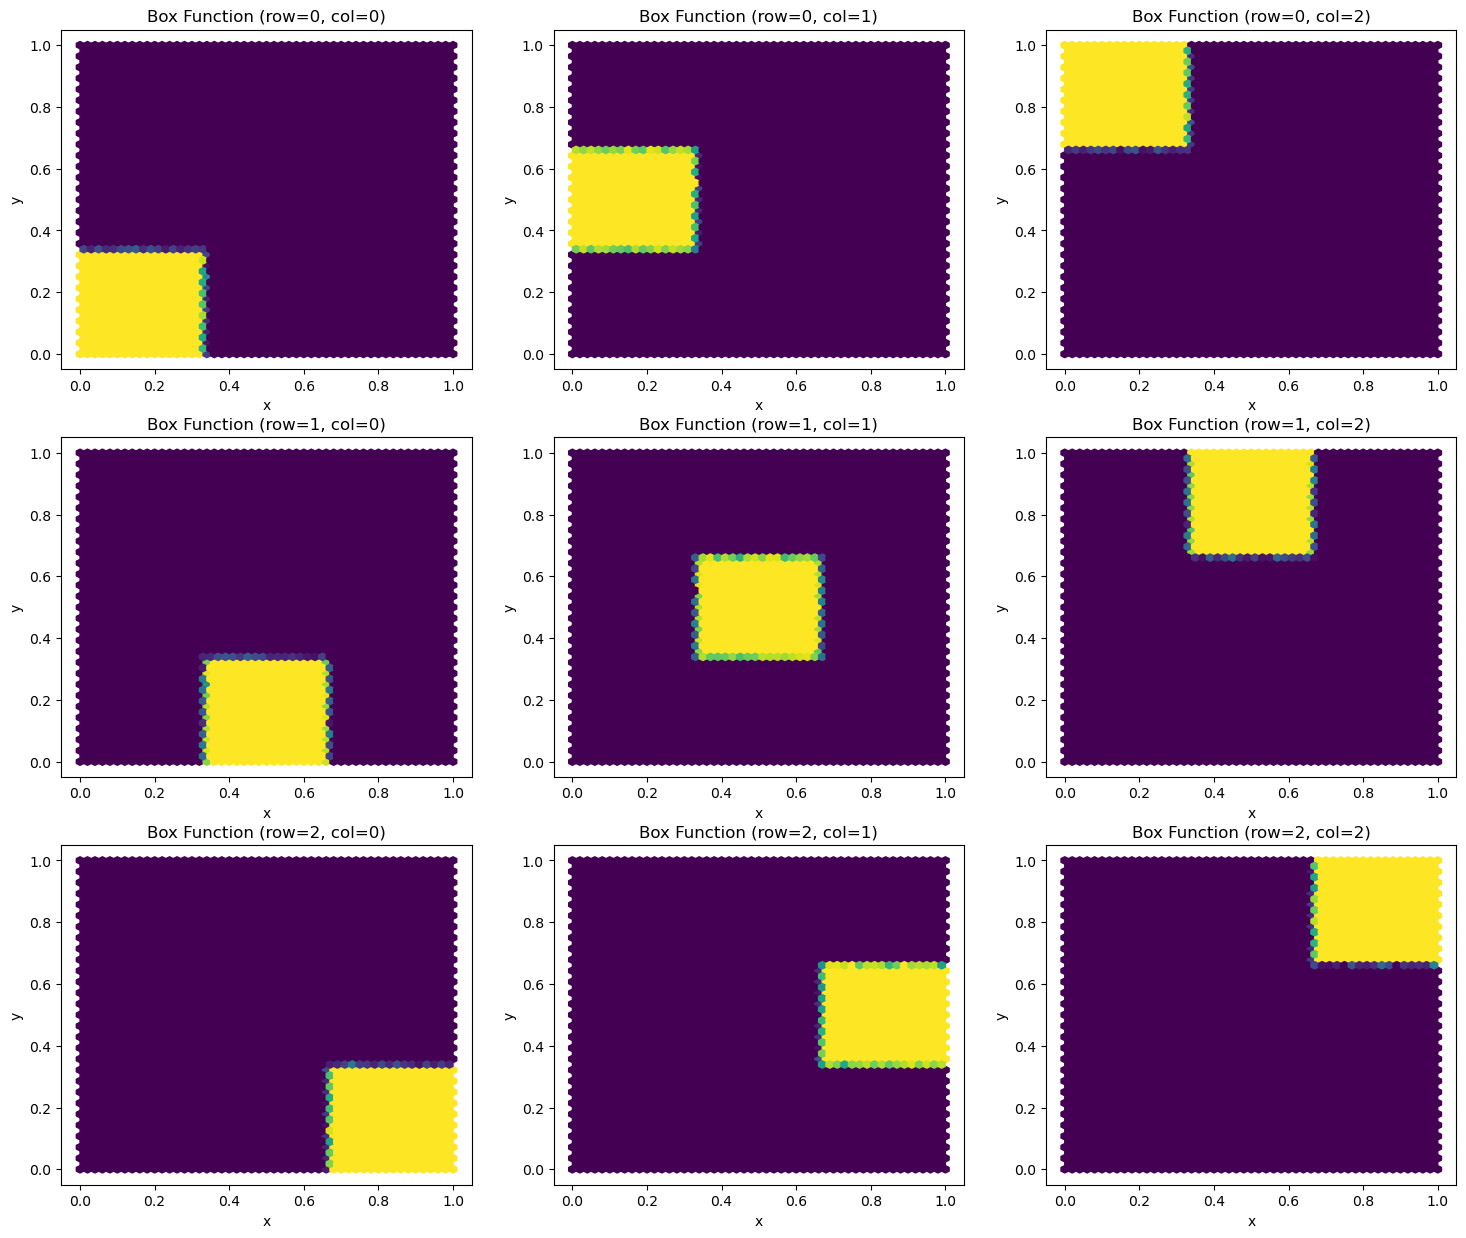

In [2]:
%autoreload 2
from infidictionary.dictionaries import BoxDictionary
from infidictionary.domain_samplers import SquareSampler

box_basis = BoxDictionary(
    domain_dim=2,
    num_channels=1,
    resolution=3,
)

indices = torch.tensor([
    [[0, 0], [0, 1], [0, 2]],
    [[1, 0], [1, 1], [1, 2]],
    [[2, 0], [2, 1], [2, 2]],
], dtype=torch.long)

fig, axes = plt.subplots(
    figsize=(6 * indices.shape[0],5 * indices.shape[1]), 
    nrows=indices.shape[0], 
    ncols=indices.shape[1],
)
N = 250
xy = SquareSampler().sample(N)
indices_tensorized = indices.clone().reshape(-1, 2)
all_vals = box_basis.get_atoms(xy.to(device), indices_tensorized.to(device)).cpu()

for row in range(indices.shape[0]):
    for col in range(indices.shape[1]):
        ax = axes[row, col]
        ax.hexbin(xy[:,0], xy[:,1], C=all_vals[row * indices.shape[0] + col], gridsize=50, cmap='viridis') 
        ax.set_title(f'Box Function (row={row}, col={col})')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()
    

Here's the 1D case where we sample the indices from the index sampler:

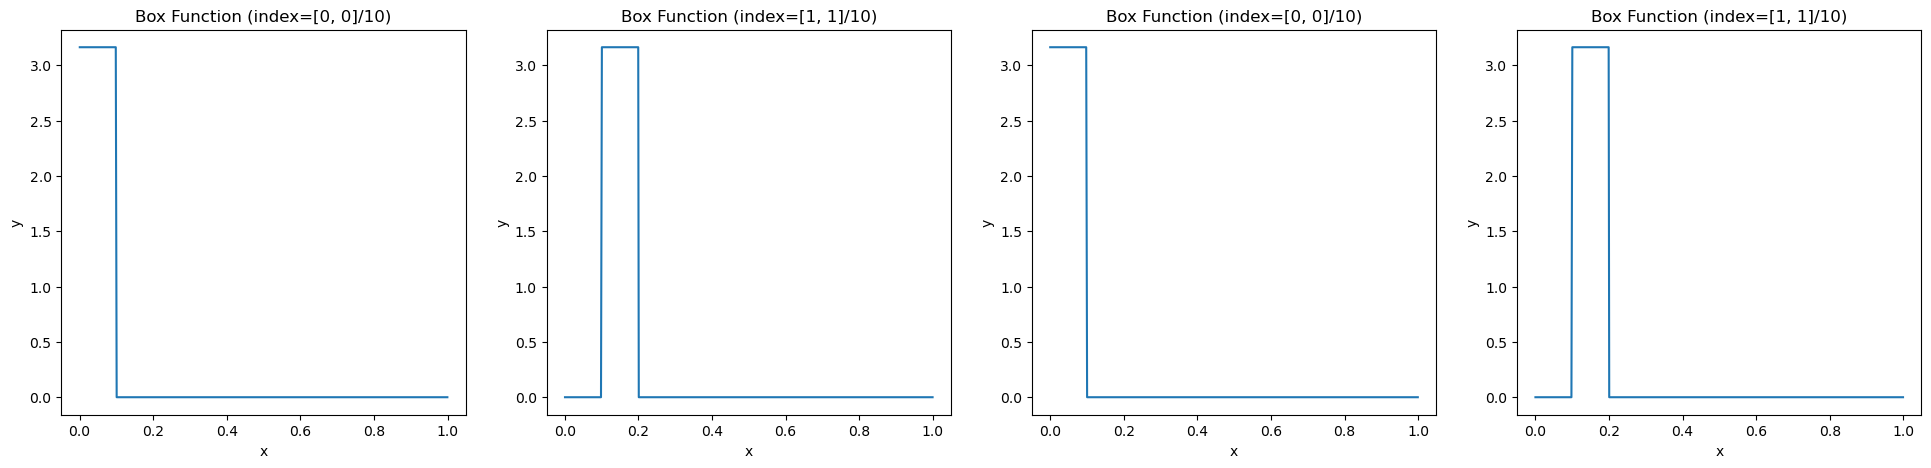

In [3]:
%autoreload 2 
from infidictionary.domain_samplers import LineSegmentSampler

random_indices = box_basis.sample_indices(4)
coords = LineSegmentSampler().sample(1000)
box_basis = BoxDictionary(
    domain_dim=1,
    num_channels=1,
    resolution=10,
)
all_vals = box_basis.get_atoms(coords.to(device), random_indices.to(device)).cpu()
fig, axes = plt.subplots(
    figsize=(6 * random_indices.shape[0],5), 
    nrows=1, 
    ncols=random_indices.shape[0],
)
for i in range(random_indices.shape[0]):
    ax = axes[i]
    # sort the coordinates and corresponding values for better visualization
    sorted_indices = torch.argsort(coords[:, 0])
    sorted_coords = coords[sorted_indices].detach().cpu()
    sorted_vals = all_vals[i][sorted_indices].detach().cpu()
    ax.plot(sorted_coords[:, 0], sorted_vals)
    ax.set_title(f'Box Function (index={random_indices[i].tolist()}/{box_basis.resolution})')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.show()

## Multi-dimensional Fourier Basis

Next, we consider the multi-dimensional Fourier basis on $\Omega = [0, 1]^d$. Each basis is indexed by two elements $i_1, ..., i_d \in \mathbb{N} \cup \{0\}$.

The one dimensional real Fourier basis is obtained via the following:
$$e_i(t) = \begin{cases}
\sqrt{2} \sin(2 \pi i t) & \text{if } i > 0 \text{ is odd}\\
\sqrt{2} \cos(2 \pi i t) & \text{if } i > 0 \text{ is even}\\
1 & \text{if } i = 0
\end{cases},$$
For the multi-dimensional case we just take their tensor products, in other words:
$$e^{i_1, i_2, \ldots, i_d}(x_1, x_2, \ldots, x_d) = \prod_{k=1}^d e^{i_k}(x_k)$$

One can check using Fubini and completeness of the 1D Fourier basis that the above is also a complete basis of the functions supported on $[0, 1]^d$ when one considers all of the indices.

ThiRun the following code to visualize a selection of 2D basis functions. Since the sequence of indices is infinite, the sampler draws each element independently from a geometric distribution with probability $p$. The choice between sine and cosine is made uniformly at random, ensuring that for any given frequency, both function types are equally likely to be selected.

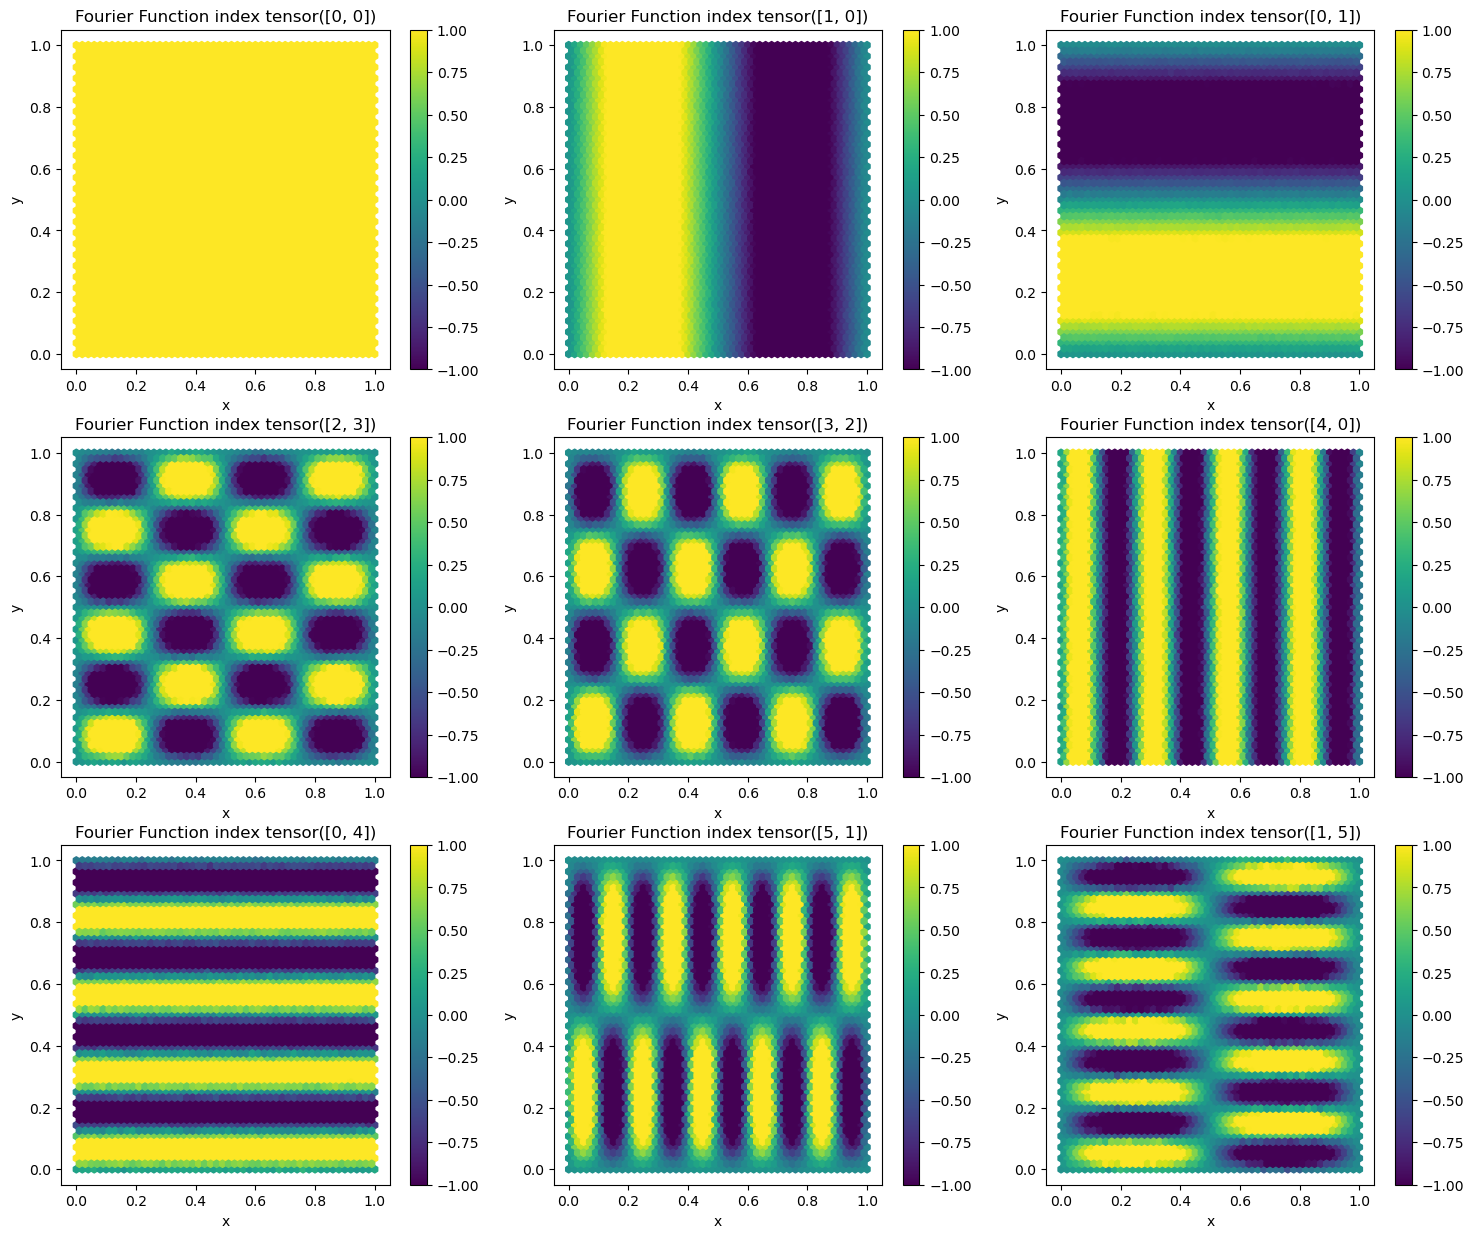

In [4]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

fourier_basis = FourierDictionary(domain_dim=2, num_channels=1, index_geom_p=0.3)
indices = torch.tensor(
    [
        [0, 0],
        [1, 0],
        [0, 1],
        [2, 3],
        [3, 2],
        [4, 0],
        [0, 4],
        [5, 1],
        [1, 5],
    ]
)
fig, axes = plt.subplots(
    figsize=(6 * 3,5 * 3), 
    nrows=3, 
    ncols=3,
)
coords = SquareSampler().sample(200)
all_vals = fourier_basis.get_atoms(coords.to(device), indices.to(device)).cpu()

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        # compute the L2
        ax.hexbin(coords[:,0], coords[:,1], C=all_vals[row * 3 + col], gridsize=50, cmap='viridis', vmin=-1, vmax=1)
        ax.set_title(f'Fourier Function index {indices[row * 3 + col]}')
        # add a colorbar
        plt.colorbar(ax.collections[0], ax=ax)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
plt.show()

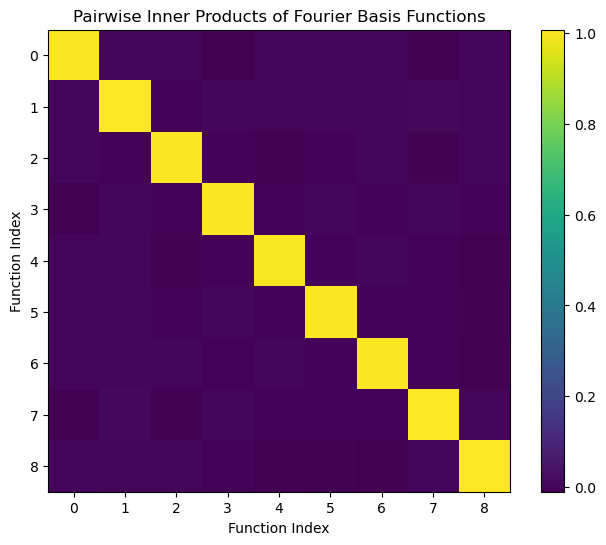

In [5]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product
inner_products = pairwise_inner_product(all_vals, all_vals)
# plot a heatmap of the inner products
plt.figure(figsize=(8, 6))
plt.imshow(inner_products, cmap='viridis')
plt.colorbar()
plt.title('Pairwise Inner Products of Fourier Basis Functions')
plt.xlabel('Function Index')
plt.ylabel('Function Index')
plt.show()

## Modeling the Captured Energy

One thing that we will use frequently in our training code is computation of the captured energy. The captured energy essentially tries to estimate the expected value of the coefficients weighted according to the probability distribution of the index. Since the captured energy function returns random values used for SGD, we pick two different signals, one of them low frequency and another high frequency and then we try to plot the captured energy of them and compare their histograms. It is expected that the captured energy for the lower frequency object is higher.

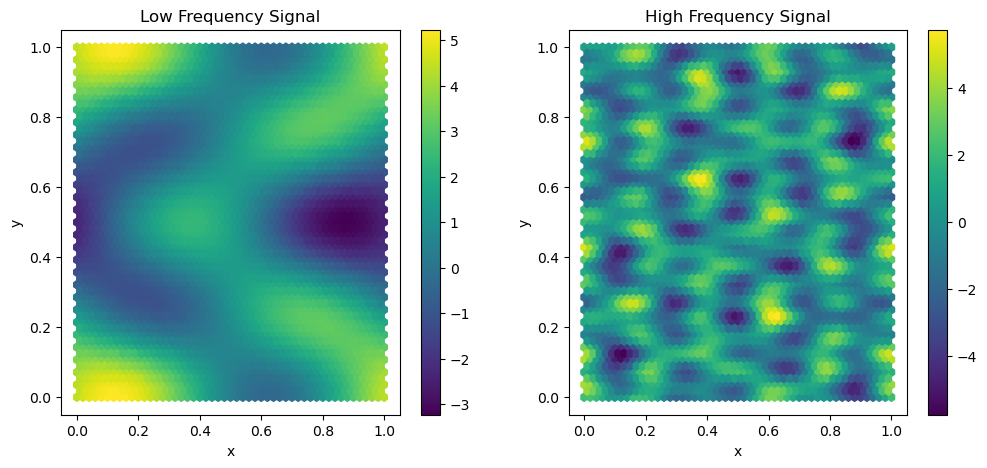

In [7]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary


fourier_basis = FourierDictionary(domain_dim=2, num_channels=1, index_geom_p=0.3)
high_freq_indices = torch.tensor([
    [-5, 0],
    [-4, 3],
    [-3, 10],
    [2, -4],
])
low_freq_indices = torch.tensor([
    [0, -1],
    [1, -2],
    [0, 0],
    [-1, -1],
])

low_frequency_signal = fourier_basis.get_atoms(coords.to(device), low_freq_indices.to(device)).sum(dim=0).cpu()
high_frequency_atoms = fourier_basis.get_atoms(coords.to(device), high_freq_indices.to(device)).sum(dim=0).cpu()

# plot the two signals
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hexbin(coords[:,0], coords[:,1], C=low_frequency_signal, gridsize=50, cmap='viridis')
plt.colorbar()
plt.title('Low Frequency Signal')
plt.xlabel('x')
plt.ylabel('y')
plt.subplot(1, 2, 2)
plt.hexbin(coords[:,0], coords[:,1], C=high_frequency_atoms, gridsize=50, cmap='viridis')
plt.colorbar()
plt.title('High Frequency Signal')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

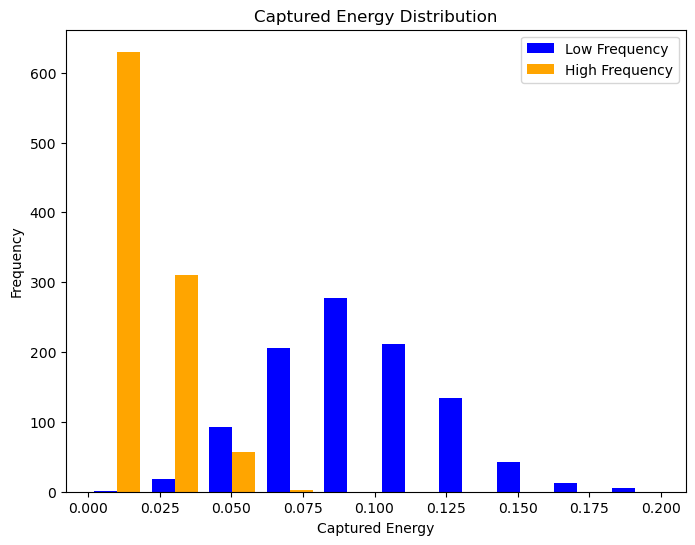

In [8]:
all_signals = torch.stack([low_frequency_signal, high_frequency_atoms])
all_captured_energies = []
for _ in range(1000):
    captured_energy = fourier_basis.estimate_captured_energy(
        coords=coords.to(device),
        logabsdet=torch.zeros(coords.shape[0], device=device),  # logabsdet is not used in FourierDictionary, so we can just pass a dummy value
        values=all_signals.to(device), # (B, N, C)
        num_samples=100,
        method='monte_carlo'
    )
    all_captured_energies.append(captured_energy.cpu())
all_captured_energies = torch.stack(all_captured_energies)  # (num_trials, B)
# plot a histogram of the captured energies with different colors for the low and high frequency signals
plt.figure(figsize=(8, 6))
plt.hist(all_captured_energies,color=['blue', 'orange'], label=['Low Frequency', 'High Frequency'])
plt.title('Captured Energy Distribution')
plt.xlabel('Captured Energy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

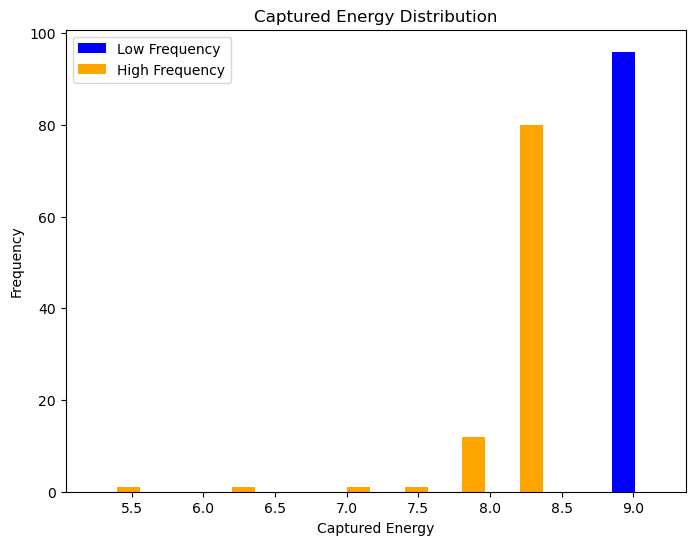

In [9]:
all_signals = torch.stack([low_frequency_signal, high_frequency_atoms])
all_captured_energies = []
for nyquist_freq in range(32, 128):
    captured_energy = fourier_basis.estimate_captured_energy(
        coords=coords.to(device),
        logabsdet=torch.zeros(coords.shape[0], device=device),  # logabsdet is not used in FourierDictionary, so we can just pass a dummy value
        values=all_signals.to(device), # (B, N, C)
        nyquist=nyquist_freq,
        method='nufft',
    )
    all_captured_energies.append(captured_energy.cpu())
all_captured_energies = torch.stack(all_captured_energies)  # (num_trials, B)
# plot a histogram of the captured energies with different colors for the low and high frequency signals
plt.figure(figsize=(8, 6))
plt.hist(all_captured_energies,color=['blue', 'orange'], label=['Low Frequency', 'High Frequency'])
plt.title('Captured Energy Distribution')
plt.xlabel('Captured Energy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [10]:
import pytorch_finufft.functional as finufft
nyquist = 32

points = coords.transpose(0, 1).contiguous().to(device)
values = all_signals.permute(0, 2, 1).contiguous().to(device).to(dtype=torch.complex64)

dft = torch.sqrt(torch.tensor(2.0)) * finufft.finufft_type1(
    points=points,  # Transpose to shape (d, N) as expected by finufft
    values=values,  # Reshape to (B*C, N)
    output_shape=(nyquist * 2 + 1, nyquist * 2 + 1),
    modeord=0,
).permute(0, 2, 3, 1) / points.shape[1] # [:, :, :64, :64]  # Reshape back to (B, C, H, W) and take the low-frequency components

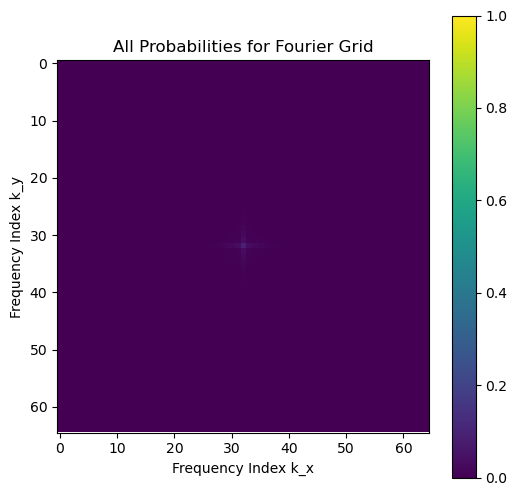

In [11]:
probability_weights = fourier_basis.compute_grid_weights(nyquist=nyquist) # (256, 256)
all_probas = torch.zeros((2*nyquist+1, 2*nyquist+1))
all_probas[nyquist:, nyquist:] += probability_weights
all_probas[nyquist:, :nyquist+1] += torch.flip(probability_weights, dims=[1])
all_probas[:nyquist+1, nyquist:] += torch.flip(probability_weights, dims=[0])
all_probas[:nyquist+1, :nyquist+1] += torch.flip(probability_weights, dims=[0, 1])
all_probas /= 4
# plot the heatmap of the all_probas
plt.figure(figsize=(6, 6))
plt.imshow(all_probas.cpu(), cmap='viridis', vmin=0, vmax=1.0)
plt.colorbar()
plt.title('All Probabilities for Fourier Grid')
plt.xlabel('Frequency Index k_x')
plt.ylabel('Frequency Index k_y')
plt.show()

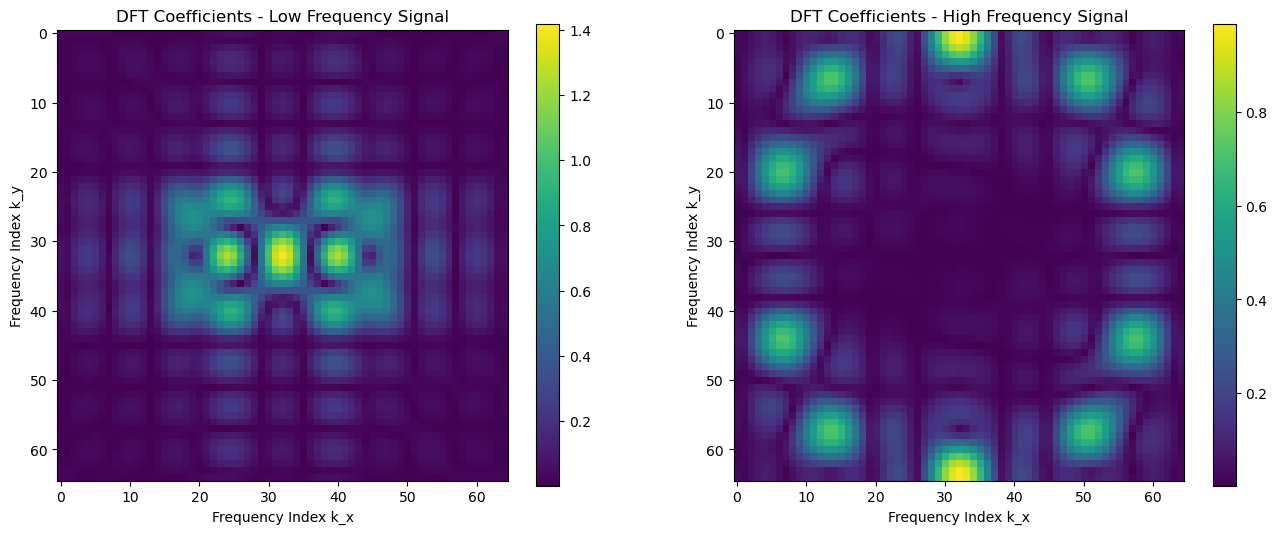

In [12]:
# plot the dfts of the two signals
plt.figure(figsize=(16, 6))
# first subplot for low frequency signal
plt.subplot(1, 2, 1)
plt.imshow(dft[0].abs().cpu(), cmap='viridis')
plt.colorbar()
plt.title('DFT Coefficients - Low Frequency Signal')
plt.xlabel('Frequency Index k_x')
plt.ylabel('Frequency Index k_y')
# second subplot for high frequency signal
plt.subplot(1, 2, 2)
plt.imshow(dft[1].abs().cpu(), cmap='viridis')
plt.colorbar()
plt.title('DFT Coefficients - High Frequency Signal')
plt.xlabel('Frequency Index k_x')
plt.ylabel('Frequency Index k_y')
plt.show()

In [13]:
torch.mean(dft[0].abs() ** 2)

tensor(0.0676, device='cuda:0')

In [14]:
captured_energy1 = (dft[0].abs() ** 2 * all_probas.to(device)).sum()
captured_energy2 = (dft[1].abs() ** 2 * all_probas.to(device)).sum()
print(f'Captured Energy for Low Frequency Signal: {captured_energy1.item():.4f}')
print(f'Captured Energy for High Frequency Signal: {captured_energy2.item():.4f}')

Captured Energy for Low Frequency Signal: 9.0008
Captured Energy for High Frequency Signal: 5.1983


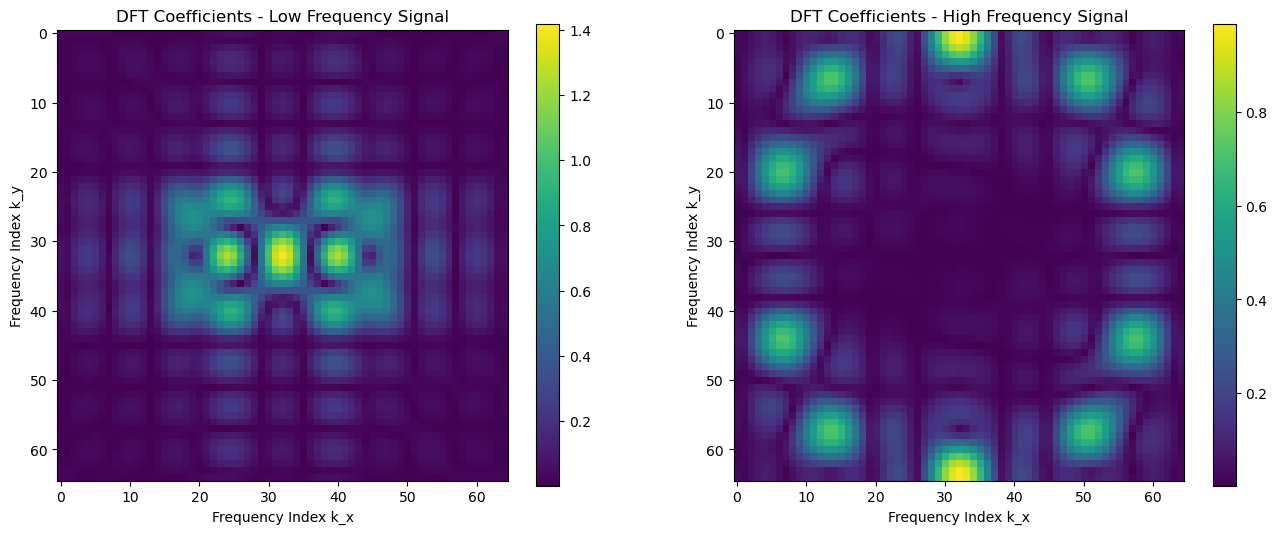

In [15]:
# visualize frequencies for both low and high frequency signals
plt.figure(figsize=(16, 6))
# first subplot for low frequency signal
plt.subplot(1, 2, 1)
plt.imshow(dft[0].abs().cpu(), cmap='viridis')
plt.colorbar()
plt.title('DFT Coefficients - Low Frequency Signal')
plt.xlabel('Frequency Index k_x')
plt.ylabel('Frequency Index k_y')
# second subplot for high frequency signal
plt.subplot(1, 2, 2)
plt.imshow(dft[1].abs().cpu(), cmap='viridis')
plt.colorbar()
plt.title('DFT Coefficients - High Frequency Signal')
plt.xlabel('Frequency Index k_x')
plt.ylabel('Frequency Index k_y')
plt.show()

In [16]:
import torch
import pytorch_finufft.functional as finufft

def compute_2d_real_coeffs(coords, values, max_i=32):
    """
    Computes coefficients for the 2D Real Fourier Basis up to index max_i.
    i_1, i_2 are indices from 0 to max_i.
    
    Returns:
        A tensor of shape (Batch, max_i, max_i) containing the real coefficients.
    """
    # 1. Determine necessary FFT size
    # If we want basis index i=32, that corresponds to frequency k=16.
    # We need positive and negative freqs, so grid size ~ 34.
    max_k = (max_i // 2) + 1
    grid_size = max_k * 2 + 2 
    
    # 2. Run FinUFFT (Type 1)
    # output_shape must be 2D tuple
    # modeord=1 gives standard FFT order: [0, 1, ... -2, -1]
    complex_grid = finufft.finufft_type1(
        points=coords.transpose(0, 1).contiguous(),
        values=values.permute(0, 2, 1).contiguous().to(dtype=torch.complex64),
        output_shape=(grid_size, grid_size),
        modeord=1, 
    )
    
    # Normalize by N (Number of points)
    N = coords.shape[0]
    complex_grid = complex_grid / N

    # 3. Extract Coefficients
    B, C, H, W = complex_grid.shape
    real_coeffs = torch.zeros(B, C, max_i, max_i, device=coords.device)

    # Helper to get k and type from index i
    # type: 0=DC, 1=Sin, 2=Cos
    def get_k_type(idx):
        if idx == 0: return 0, 0
        k = (idx + 1) // 2
        t = 1 if (idx % 2 != 0) else 2 # 1 for Odd(Sin), 2 for Even(Cos)
        return k, t

    # Loop over the requested 2D basis indices
    for i1 in range(max_i):
        for i2 in range(max_i):
            k1, t1 = get_k_type(i1)
            k2, t2 = get_k_type(i2)
            
            # --- CASE 1: DC (0, 0) ---
            if k1 == 0 and k2 == 0:
                val = complex_grid[:, :, 0, 0].real
            
            # --- CASE 2: 1D Modes (one k is 0) ---
            elif k1 == 0: # (1, cos(k2*y)) or (1, sin(k2*y))
                # Just like the 1D case, look at index (0, k2)
                c = complex_grid[:, :, 0, k2]
                if t2 == 1: val = -torch.sqrt(torch.tensor(2.0)) * c.imag * 2
                else:       val =  torch.sqrt(torch.tensor(2.0)) * c.real * 2
            
            elif k2 == 0: # (sin(k1*x), 1) etc
                # Look at index (k1, 0)
                c = complex_grid[:, :, k1, 0]
                if t1 == 1: val = -torch.sqrt(torch.tensor(2.0)) * c.imag * 2
                else:       val =  torch.sqrt(torch.tensor(2.0)) * c.real * 2

            # --- CASE 3: 2D Mixed Modes (The tricky part) ---
            else:
                # We need TWO complex values to solve this:
                # A = c[k1, k2]   (Freq +k1, +k2)
                # B = c[k1, -k2]  (Freq +k1, -k2) -> index [k1, -k2] in array
                
                # Note: In standard FFT order, index -k is at grid_size - k
                c_pos = complex_grid[:, :, k1, k2]
                c_neg = complex_grid[:, :, k1, grid_size - k2]
                
                # We apply the 2D Real Fourier Formulas
                # Factor 2 comes from sqrt(2)*sqrt(2)
                
                if t1 == 2 and t2 == 2:   # Cos(x)Cos(y)
                    # 2 * Re(A + B)
                    val = 2.0 * (c_pos.real + c_neg.real)
                    
                elif t1 == 1 and t2 == 1: # Sin(x)Sin(y)
                    # -2 * Re(A - B)
                    val = -2.0 * (c_pos.real - c_neg.real)
                    
                elif t1 == 2 and t2 == 1: # Cos(x)Sin(y)
                    # -2 * Im(A - B)
                    val = -2.0 * (c_pos.imag - c_neg.imag)
                    
                elif t1 == 1 and t2 == 2: # Sin(x)Cos(y)
                    # -2 * Im(A + B)
                    val = -2.0 * (c_pos.imag + c_neg.imag)

            real_coeffs[:, :, i1, i2] = val

    return real_coeffs

In [17]:
coeffs = compute_2d_real_coeffs(coords, all_signals, max_i=128)

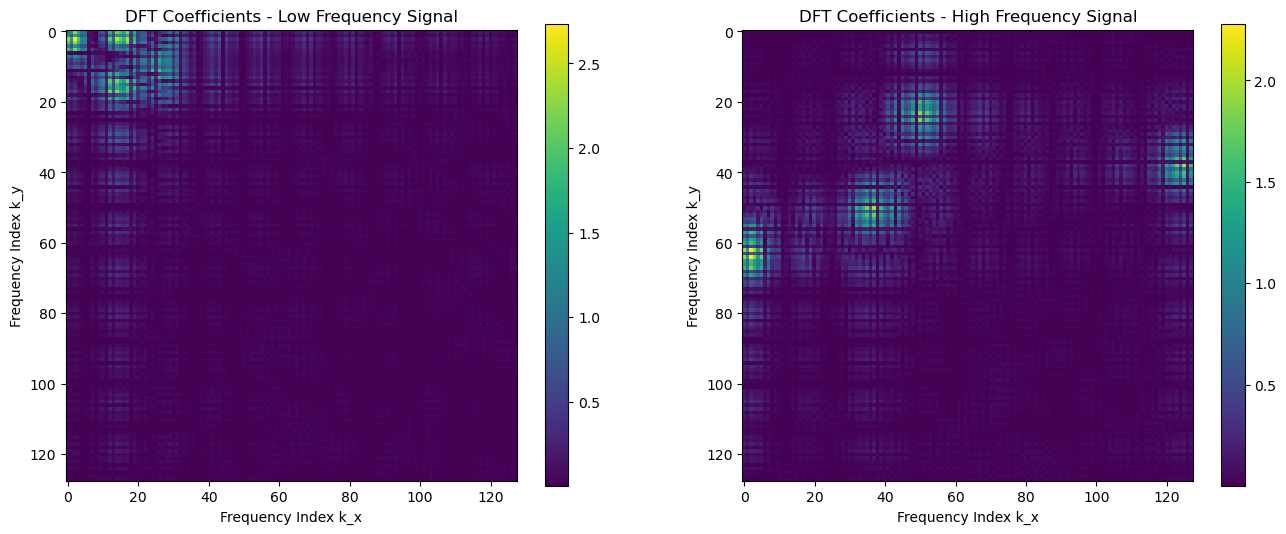

In [18]:
# visualize frequencies for both low and high frequency signals
plt.figure(figsize=(16, 6))
# first subplot for low frequency signal
plt.subplot(1, 2, 1)
plt.imshow(coeffs[0][0].abs().cpu(), cmap='viridis')
plt.colorbar()
plt.title('DFT Coefficients - Low Frequency Signal')
plt.xlabel('Frequency Index k_x')
plt.ylabel('Frequency Index k_y')
# second subplot for high frequency signal
plt.subplot(1, 2, 2)
plt.imshow(coeffs[1][0].abs().cpu(), cmap='viridis')
plt.colorbar()
plt.title('DFT Coefficients - High Frequency Signal')
plt.xlabel('Frequency Index k_x')
plt.ylabel('Frequency Index k_y')
plt.show()